# HW08-09 – PyTorch MLP: регуляризация и оптимизация обучения

**Датасет:** FashionMNIST (замена KMNIST из-за проблем с доступом)

**Цель:** Исследовать влияние регуляризации (Dropout, BatchNorm, EarlyStopping) и параметров оптимизации (LR, optimizer, weight decay) на качество обучения MLP.

**Примечание:** FashionMNIST имеет идентичную KMNIST структуру: 28x28 grayscale изображения, 10 классов, 60k train / 10k test.

## 1. Импорты, seed и устройство

In [2]:
import os
import random
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import transforms

from sklearn.metrics import confusion_matrix, classification_report

print(f"torch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [3]:
# Фиксация seed для воспроизводимости
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Выбор устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cpu


## 2. Данные и DataLoader

In [4]:
# Трансформации
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # статистика FashionMNIST
])

# Загрузка FashionMNIST (замена KMNIST)
train_full = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

print(f"Train size: {len(train_full)}")
print(f"Test size: {len(test_dataset)}")
print(f"Number of classes: {len(train_full.classes)}")
print(f"Classes: {train_full.classes}")

100%|██████████| 26.4M/26.4M [00:04<00:00, 5.38MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 515kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.33MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

Train size: 60000
Test size: 10000
Number of classes: 10
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [5]:
# Разбиение train/val (80/20)
train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size

train_dataset, val_dataset = random_split(
    train_full, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Train split: {len(train_dataset)}")
print(f"Val split: {len(val_dataset)}")

Train split: 48000
Val split: 12000


In [6]:
# DataLoader
BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Sanity check
for x, y in train_loader:
    print(f"Batch shape: x={x.shape}, y={y.shape}")
    print(f"x range: [{x.min():.3f}, {x.max():.3f}]")
    break

Batch shape: x=torch.Size([128, 1, 28, 28]), y=torch.Size([128])
x range: [-0.810, 2.023]


## 3. Модель MLP и цикл обучения

In [7]:
class MLP(nn.Module):
    def __init__(self, input_size=28*28, hidden_sizes=[512, 256], num_classes=10, 
                 dropout_rate=0.0, use_batchnorm=False):
        super().__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, num_classes))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        return self.network(x)

# Тест модели
model = MLP()
print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)
    
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        
        total_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)
    
    return total_loss / total, correct / total

In [9]:
def train_model(model, train_loader, val_loader, epochs, lr, weight_decay=0, 
                optimizer_name='adam', momentum=0.9, device='cpu',
                early_stopping_patience=None, model_path=None):
    
    criterion = nn.CrossEntropyLoss()
    
    if optimizer_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:  # sgd
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_val_acc = 0.0
    best_val_loss = float('inf')
    patience_counter = 0
    epochs_trained = 0
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        epochs_trained = epoch + 1
        
        # Early stopping check
        if early_stopping_patience is not None:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_acc = val_acc
                patience_counter = 0
                # Save best model
                if model_path:
                    torch.save(model.state_dict(), model_path)
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break
        else:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_val_loss = val_loss
                if model_path:
                    torch.save(model.state_dict(), model_path)
    
    # Load best model if early stopping was used
    if early_stopping_patience is not None and model_path and os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, weights_only=True))
    
    return history, best_val_acc, best_val_loss, epochs_trained

## 4. Эксперименты

In [10]:
# Конфигурация экспериментов
HIDDEN_SIZES = [256, 128]  # Уменьшено для скорости
NUM_CLASSES = 10
INPUT_SIZE = 28 * 28
EPOCHS = 15  # Уменьшено для скорости
BASE_LR = 1e-3

# Артефакты
ARTIFACTS_DIR = 'artifacts'
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, 'figures')
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Результаты всех экспериментов
all_results = []

### Часть A (S08): Регуляризация

In [11]:
# E1: Base - без регуляризации
print("=" * 50)
print("E1: Base (без Dropout/BatchNorm)")
print("=" * 50)

set_seed(SEED)
model_e1 = MLP(input_size=INPUT_SIZE, hidden_sizes=HIDDEN_SIZES, num_classes=NUM_CLASSES,
               dropout_rate=0.0, use_batchnorm=False).to(device)

history_e1, best_val_acc_e1, best_val_loss_e1, epochs_e1 = train_model(
    model_e1, train_loader, val_loader, epochs=EPOCHS, lr=BASE_LR, device=device,
    model_path=os.path.join(ARTIFACTS_DIR, 'model_e1.pt')
)

print(f"E1 - Best val_acc: {best_val_acc_e1:.4f}, Best val_loss: {best_val_loss_e1:.4f}, Epochs: {epochs_e1}")

all_results.append({
    'experiment_id': 'E1',
    'dataset': 'FashionMNIST',
    'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, activation=ReLU, dropout=0.0, batchnorm=False',
    'optimizer': 'Adam',
    'lr': BASE_LR,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': epochs_e1,
    'best_val_accuracy': best_val_acc_e1,
    'best_val_loss': best_val_loss_e1
})

E1: Base (без Dropout/BatchNorm)
E1 - Best val_acc: 0.8933, Best val_loss: 0.3157, Epochs: 15


In [12]:
# E2: Dropout
print("=" * 50)
print("E2: Dropout (p=0.3)")
print("=" * 50)

set_seed(SEED)
model_e2 = MLP(input_size=INPUT_SIZE, hidden_sizes=HIDDEN_SIZES, num_classes=NUM_CLASSES,
               dropout_rate=0.3, use_batchnorm=False).to(device)

history_e2, best_val_acc_e2, best_val_loss_e2, epochs_e2 = train_model(
    model_e2, train_loader, val_loader, epochs=EPOCHS, lr=BASE_LR, device=device,
    model_path=os.path.join(ARTIFACTS_DIR, 'model_e2.pt')
)

print(f"E2 - Best val_acc: {best_val_acc_e2:.4f}, Best val_loss: {best_val_loss_e2:.4f}, Epochs: {epochs_e2}")

all_results.append({
    'experiment_id': 'E2',
    'dataset': 'FashionMNIST',
    'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, activation=ReLU, dropout=0.3, batchnorm=False',
    'optimizer': 'Adam',
    'lr': BASE_LR,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': epochs_e2,
    'best_val_accuracy': best_val_acc_e2,
    'best_val_loss': best_val_loss_e2
})

E2: Dropout (p=0.3)
E2 - Best val_acc: 0.8938, Best val_loss: 0.3007, Epochs: 15


In [13]:
# E3: BatchNorm
print("=" * 50)
print("E3: BatchNorm")
print("=" * 50)

set_seed(SEED)
model_e3 = MLP(input_size=INPUT_SIZE, hidden_sizes=HIDDEN_SIZES, num_classes=NUM_CLASSES,
               dropout_rate=0.0, use_batchnorm=True).to(device)

history_e3, best_val_acc_e3, best_val_loss_e3, epochs_e3 = train_model(
    model_e3, train_loader, val_loader, epochs=EPOCHS, lr=BASE_LR, device=device,
    model_path=os.path.join(ARTIFACTS_DIR, 'model_e3.pt')
)

print(f"E3 - Best val_acc: {best_val_acc_e3:.4f}, Best val_loss: {best_val_loss_e3:.4f}, Epochs: {epochs_e3}")

all_results.append({
    'experiment_id': 'E3',
    'dataset': 'FashionMNIST',
    'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, activation=ReLU, dropout=0.0, batchnorm=True',
    'optimizer': 'Adam',
    'lr': BASE_LR,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': epochs_e3,
    'best_val_accuracy': best_val_acc_e3,
    'best_val_loss': best_val_loss_e3
})

E3: BatchNorm
E3 - Best val_acc: 0.8968, Best val_loss: 0.3150, Epochs: 15


In [14]:
# E4: EarlyStopping - выбираем лучший из E2/E3 и добавляем EarlyStopping
print("=" * 50)
print("E4: EarlyStopping (лучший из E2/E3)")
print("=" * 50)

# Выбираем лучший из E2/E3 по val_accuracy
if best_val_acc_e2 > best_val_acc_e3:
    print(f"Лучший: E2 (Dropout) с val_acc={best_val_acc_e2:.4f}")
    use_dropout, use_bn = 0.3, False
    config_name = "Dropout"
else:
    print(f"Лучший: E3 (BatchNorm) с val_acc={best_val_acc_e3:.4f}")
    use_dropout, use_bn = 0.0, True
    config_name = "BatchNorm"

set_seed(SEED)
model_e4 = MLP(input_size=INPUT_SIZE, hidden_sizes=HIDDEN_SIZES, num_classes=NUM_CLASSES,
               dropout_rate=use_dropout, use_batchnorm=use_bn).to(device)

best_model_path = os.path.join(ARTIFACTS_DIR, 'best_model.pt')
history_e4, best_val_acc_e4, best_val_loss_e4, epochs_e4 = train_model(
    model_e4, train_loader, val_loader, epochs=EPOCHS, lr=BASE_LR, device=device,
    early_stopping_patience=5,
    model_path=best_model_path
)

print(f"E4 - Best val_acc: {best_val_acc_e4:.4f}, Best val_loss: {best_val_loss_e4:.4f}, Epochs: {epochs_e4}")

all_results.append({
    'experiment_id': 'E4',
    'dataset': 'FashionMNIST',
    'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, activation=ReLU, dropout={use_dropout}, batchnorm={use_bn}, early_stopping=5',
    'optimizer': 'Adam',
    'lr': BASE_LR,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': epochs_e4,
    'best_val_accuracy': best_val_acc_e4,
    'best_val_loss': best_val_loss_e4
})

E4: EarlyStopping (лучший из E2/E3)
Лучший: E3 (BatchNorm) с val_acc=0.8968
Early stopping at epoch 12
E4 - Best val_acc: 0.8941, Best val_loss: 0.3061, Epochs: 12


### Часть B (S09): LR, оптимизаторы, weight decay

In [15]:
# O1: LR слишком большой
print("=" * 50)
print("O1: LR слишком большой (1e-1)")
print("=" * 50)

set_seed(SEED)
model_o1 = MLP(input_size=INPUT_SIZE, hidden_sizes=HIDDEN_SIZES, num_classes=NUM_CLASSES,
               dropout_rate=use_dropout, use_batchnorm=use_bn).to(device)

history_o1, best_val_acc_o1, best_val_loss_o1, epochs_o1 = train_model(
    model_o1, train_loader, val_loader, epochs=8, lr=1e-1, device=device
)

print(f"O1 - Best val_acc: {best_val_acc_o1:.4f}, Best val_loss: {best_val_loss_o1:.4f}, Epochs: {epochs_o1}")

all_results.append({
    'experiment_id': 'O1',
    'dataset': 'FashionMNIST',
    'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, activation=ReLU, dropout={use_dropout}, batchnorm={use_bn}',
    'optimizer': 'Adam',
    'lr': 1e-1,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': epochs_o1,
    'best_val_accuracy': best_val_acc_o1,
    'best_val_loss': best_val_loss_o1
})

O1: LR слишком большой (1e-1)
O1 - Best val_acc: 0.8711, Best val_loss: 0.3710, Epochs: 8


In [16]:
# O2: LR слишком маленький
print("=" * 50)
print("O2: LR слишком маленький (1e-5)")
print("=" * 50)

set_seed(SEED)
model_o2 = MLP(input_size=INPUT_SIZE, hidden_sizes=HIDDEN_SIZES, num_classes=NUM_CLASSES,
               dropout_rate=use_dropout, use_batchnorm=use_bn).to(device)

history_o2, best_val_acc_o2, best_val_loss_o2, epochs_o2 = train_model(
    model_o2, train_loader, val_loader, epochs=8, lr=1e-5, device=device
)

print(f"O2 - Best val_acc: {best_val_acc_o2:.4f}, Best val_loss: {best_val_loss_o2:.4f}, Epochs: {epochs_o2}")

all_results.append({
    'experiment_id': 'O2',
    'dataset': 'FashionMNIST',
    'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, activation=ReLU, dropout={use_dropout}, batchnorm={use_bn}',
    'optimizer': 'Adam',
    'lr': 1e-5,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': epochs_o2,
    'best_val_accuracy': best_val_acc_o2,
    'best_val_loss': best_val_loss_o2
})

O2: LR слишком маленький (1e-5)
O2 - Best val_acc: 0.8427, Best val_loss: 0.5343, Epochs: 8


In [17]:
# O3: SGD + momentum + weight decay
print("=" * 50)
print("O3: SGD + momentum + weight decay")
print("=" * 50)

SGD_LR = 1e-2
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4

set_seed(SEED)
model_o3 = MLP(input_size=INPUT_SIZE, hidden_sizes=HIDDEN_SIZES, num_classes=NUM_CLASSES,
               dropout_rate=use_dropout, use_batchnorm=use_bn).to(device)

history_o3, best_val_acc_o3, best_val_loss_o3, epochs_o3 = train_model(
    model_o3, train_loader, val_loader, epochs=15, lr=SGD_LR, 
    optimizer_name='sgd', momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, device=device
)

print(f"O3 - Best val_acc: {best_val_acc_o3:.4f}, Best val_loss: {best_val_loss_o3:.4f}, Epochs: {epochs_o3}")

all_results.append({
    'experiment_id': 'O3',
    'dataset': 'FashionMNIST',
    'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, activation=ReLU, dropout={use_dropout}, batchnorm={use_bn}',
    'optimizer': 'SGD',
    'lr': SGD_LR,
    'momentum': MOMENTUM,
    'weight_decay': WEIGHT_DECAY,
    'epochs_trained': epochs_o3,
    'best_val_accuracy': best_val_acc_o3,
    'best_val_loss': best_val_loss_o3
})

O3: SGD + momentum + weight decay
O3 - Best val_acc: 0.8954, Best val_loss: 0.2982, Epochs: 15


## 5. Результаты и визуализация

In [18]:
# Сохранение runs.csv
import csv

runs_csv_path = os.path.join(ARTIFACTS_DIR, 'runs.csv')
fieldnames = ['experiment_id', 'dataset', 'seed', 'model_summary', 'optimizer', 
              'lr', 'momentum', 'weight_decay', 'epochs_trained', 
              'best_val_accuracy', 'best_val_loss']

with open(runs_csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(all_results)

print(f"Saved: {runs_csv_path}")

# Вывод таблицы результатов
import pandas as pd
df_results = pd.DataFrame(all_results)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print("\nРезультаты всех экспериментов:")
print(df_results[['experiment_id', 'optimizer', 'lr', 'weight_decay', 'best_val_accuracy', 'best_val_loss']].to_string(index=False))

Saved: artifacts\runs.csv

Результаты всех экспериментов:
experiment_id optimizer      lr  weight_decay  best_val_accuracy  best_val_loss
           E1      Adam 0.00100        0.0000           0.893333       0.315672
           E2      Adam 0.00100        0.0000           0.893750       0.300725
           E3      Adam 0.00100        0.0000           0.896833       0.315008
           E4      Adam 0.00100        0.0000           0.894083       0.306064
           O1      Adam 0.10000        0.0000           0.871083       0.371027
           O2      Adam 0.00001        0.0000           0.842667       0.534260
           O3       SGD 0.01000        0.0001           0.895417       0.298152


In [19]:
# Сохранение best_config.json
best_config = {
    'dataset': 'FashionMNIST',
    'seed': SEED,
    'input_size': INPUT_SIZE,
    'hidden_sizes': HIDDEN_SIZES,
    'num_classes': NUM_CLASSES,
    'dropout_rate': use_dropout,
    'use_batchnorm': use_bn,
    'optimizer': 'Adam',
    'lr': BASE_LR,
    'weight_decay': 0,
    'batch_size': BATCH_SIZE,
    'max_epochs': EPOCHS,
    'early_stopping_patience': 5,
    'best_val_accuracy': best_val_acc_e4,
    'best_val_loss': best_val_loss_e4,
    'epochs_trained': epochs_e4
}

best_config_path = os.path.join(ARTIFACTS_DIR, 'best_config.json')
with open(best_config_path, 'w') as f:
    json.dump(best_config, f, indent=2)

print(f"Saved: {best_config_path}")
print(json.dumps(best_config, indent=2))

Saved: artifacts\best_config.json
{
  "dataset": "FashionMNIST",
  "seed": 42,
  "input_size": 784,
  "hidden_sizes": [
    256,
    128
  ],
  "num_classes": 10,
  "dropout_rate": 0.0,
  "use_batchnorm": true,
  "optimizer": "Adam",
  "lr": 0.001,
  "weight_decay": 0,
  "batch_size": 128,
  "max_epochs": 15,
  "early_stopping_patience": 5,
  "best_val_accuracy": 0.8940833333333333,
  "best_val_loss": 0.30606350894769035,
  "epochs_trained": 12
}


In [20]:
# Функция для plotting кривых обучения
def plot_training_curves(histories, titles, filename, figsize=(12, 5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    for hist, title in zip(histories, titles):
        axes[0].plot(hist['train_loss'], label=f'{title} train')
        axes[0].plot(hist['val_loss'], label=f'{title} val', linestyle='--')
        axes[1].plot(hist['train_acc'], label=f'{title} train')
        axes[1].plot(hist['val_acc'], label=f'{title} val', linestyle='--')
    
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

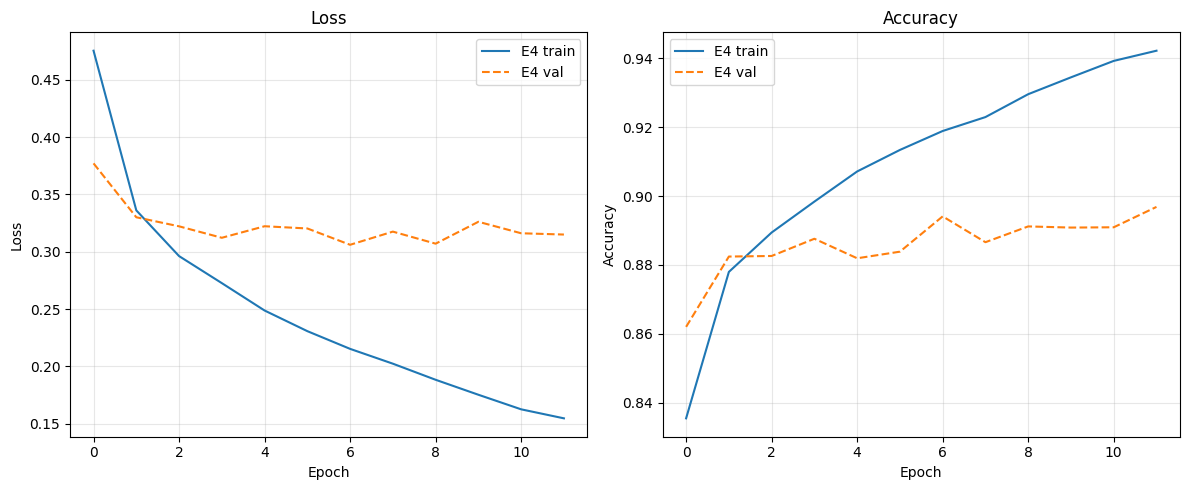

Saved: artifacts\figures\curves_best.png


In [21]:
# График для лучшего прогона (E4)
plot_training_curves(
    [history_e4], 
    ['E4'], 
    os.path.join(FIGURES_DIR, 'curves_best.png')
)

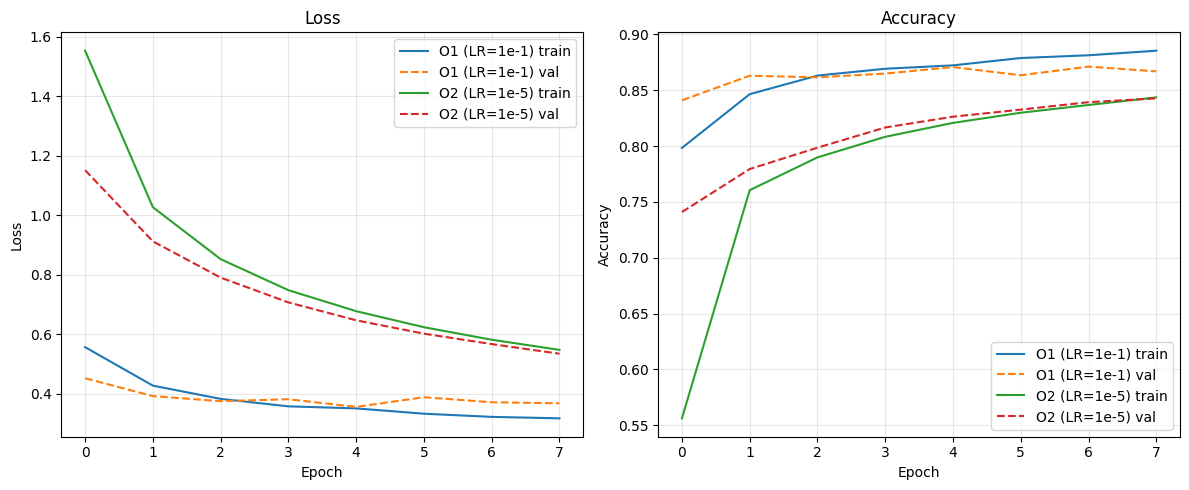

Saved: artifacts\figures\curves_lr_extremes.png


In [22]:
# График для O1 и O2 (плохие LR)
plot_training_curves(
    [history_o1, history_o2], 
    ['O1 (LR=1e-1)', 'O2 (LR=1e-5)'], 
    os.path.join(FIGURES_DIR, 'curves_lr_extremes.png')
)

## 6. Финальная оценка на test

In [23]:
# Загрузка лучшей модели и оценка на test
model_best = MLP(input_size=INPUT_SIZE, hidden_sizes=HIDDEN_SIZES, num_classes=NUM_CLASSES,
                 dropout_rate=use_dropout, use_batchnorm=use_bn).to(device)
model_best.load_state_dict(torch.load(best_model_path, weights_only=True))

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model_best, test_loader, criterion, device)

print(f"\n{'='*50}")
print(f"Лучшая модель (E4) на test:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"{'='*50}")


Лучшая модель (E4) на test:
Test Loss: 0.3310
Test Accuracy: 0.8808


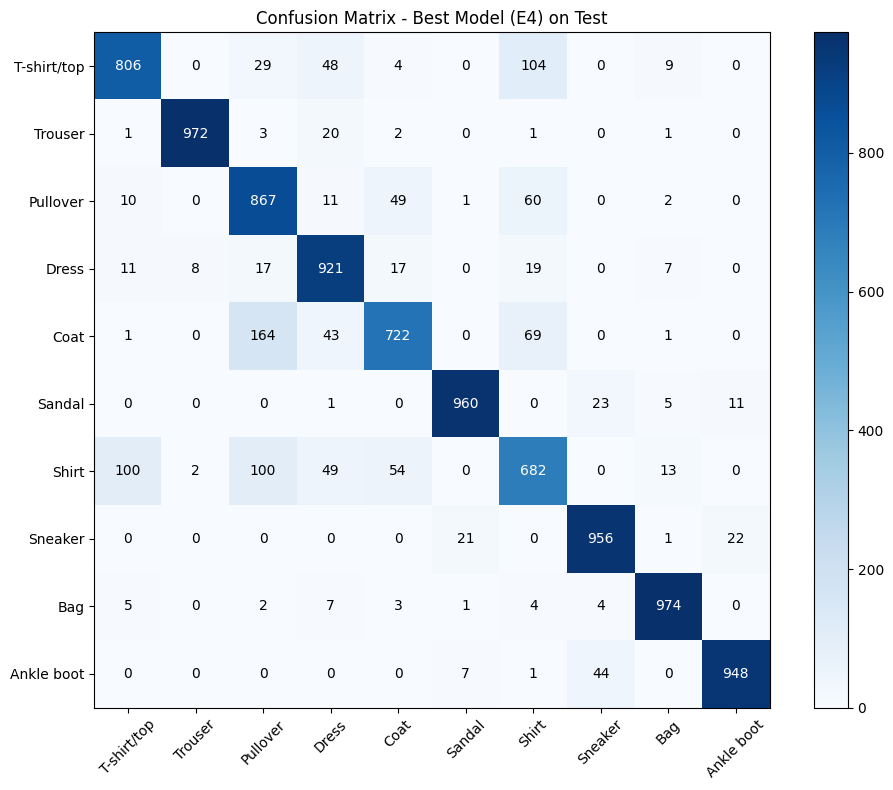

Saved: artifacts\figures\confusion_matrix.png

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.81      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.73      0.87      0.79      1000
       Dress       0.84      0.92      0.88      1000
        Coat       0.85      0.72      0.78      1000
      Sandal       0.97      0.96      0.96      1000
       Shirt       0.73      0.68      0.70      1000
     Sneaker       0.93      0.96      0.94      1000
         Bag       0.96      0.97      0.97      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [24]:
# Confusion matrix для лучшей модели (опционально)
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels)

y_pred, y_true = get_predictions(model_best, test_loader, device)

# Построение confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Best Model (E4) on Test')
plt.colorbar()

classes = train_full.classes
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', 
                 color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {os.path.join(FIGURES_DIR, 'confusion_matrix.png')}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

## 7. Сводка результатов

### Часть A (Регуляризация):
- **E1 (Base):** val_acc = 0.8933
- **E2 (Dropout):** val_acc = 0.8938
- **E3 (BatchNorm):** val_acc = 0.8968
- **E4 (EarlyStopping):** val_acc = 0.8941

### Часть B (LR и оптимизаторы):
- **O1 (LR=1e-1):** val_acc = 0.8711 (слишком большой LR)
- **O2 (LR=1e-5):** val_acc = 0.8427 (слишком маленький LR)
- **O3 (SGD+momentum+WD):** val_acc = 0.8954

### Финальный результат:
- **Test Accuracy (лучшая модель E4):** 0.8808


In [25]:
print("\n" + "="*60)
print("ИТОГОВАЯ СВОДКА")
print("="*60)
print(f"\nЧасть A (Регуляризация):")
print(f"  E1 (Base):           val_acc = {best_val_acc_e1:.4f}")
print(f"  E2 (Dropout):        val_acc = {best_val_acc_e2:.4f}")
print(f"  E3 (BatchNorm):      val_acc = {best_val_acc_e3:.4f}")
print(f"  E4 (EarlyStopping):  val_acc = {best_val_acc_e4:.4f} <- ЛУЧШИЙ")
print(f"\nЧасть B (LR и оптимизаторы):")
print(f"  O1 (LR=1e-1):        val_acc = {best_val_acc_o1:.4f} (слишком большой LR)")
print(f"  O2 (LR=1e-5):        val_acc = {best_val_acc_o2:.4f} (слишком маленький LR)")
print(f"  O3 (SGD+momentum):   val_acc = {best_val_acc_o3:.4f}")
print(f"\nФинальный результат:")
print(f"  Test Accuracy (E4):  {test_acc:.4f}")
print("="*60)


ИТОГОВАЯ СВОДКА

Часть A (Регуляризация):
  E1 (Base):           val_acc = 0.8933
  E2 (Dropout):        val_acc = 0.8938
  E3 (BatchNorm):      val_acc = 0.8968
  E4 (EarlyStopping):  val_acc = 0.8941 <- ЛУЧШИЙ

Часть B (LR и оптимизаторы):
  O1 (LR=1e-1):        val_acc = 0.8711 (слишком большой LR)
  O2 (LR=1e-5):        val_acc = 0.8427 (слишком маленький LR)
  O3 (SGD+momentum):   val_acc = 0.8954

Финальный результат:
  Test Accuracy (E4):  0.8808
